#### ============================================
#### CHANAKYA - AI Commerce Intelligence Platform
#### Layer 4: Exploratory Data Analysis (EDA)
#### Author: Devesh Shukla
#### ============================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.rcParams['figure.figsize']  = (12, 6)
plt.rcParams['font.size']       = 11
plt.rcParams['axes.spines.top']    = False
plt.rcParams['axes.spines.right']  = False
sns.set_palette('Set2')

# Paths
PROCESSED_PATH = r'C:\Users\Dell\CHANAKYA\data\processed'
EDA_PATH       = r'C:\Users\Dell\CHANAKYA\layer4_eda'

# Load processed data
df_products    = pd.read_csv(f'{PROCESSED_PATH}/products_processed.csv')
df_customers   = pd.read_csv(f'{PROCESSED_PATH}/customers_processed.csv')
df_orders      = pd.read_csv(f'{PROCESSED_PATH}/orders_processed.csv')
df_order_items = pd.read_csv(f'{PROCESSED_PATH}/order_items_processed.csv')

# Parse dates
df_orders['order_date']      = pd.to_datetime(df_orders['order_date'],      format='mixed')
df_order_items['order_date'] = pd.to_datetime(df_order_items['order_date'], format='mixed')

print("=" * 50)
print("   CHANAKYA — LAYER 4: EDA")
print("=" * 50)
print(f"\nData loaded successfully!")
print(f"  Products    : {len(df_products):,} records")
print(f"  Customers   : {len(df_customers):,} records")
print(f"  Orders      : {len(df_orders):,} records")
print(f"  Order Items : {len(df_order_items):,} records")
print(f"\nEDA started!")

   CHANAKYA — LAYER 4: EDA

Data loaded successfully!
  Products    : 50 records
  Customers   : 1,000 records
  Orders      : 5,010 records
  Order Items : 8,769 records

EDA started!


#### ============================================
#### EDA 1 — REVENUE ANALYSIS
#### ============================================

   REVENUE ANALYSIS

Key Business Metrics:
  Total Revenue       : Rs. 26,713,763.75
  Total Orders        : 3,508
  Avg Order Value     : Rs. 7,615.10
  Total Units Sold    : 8,560
  Unique Customers    : 971


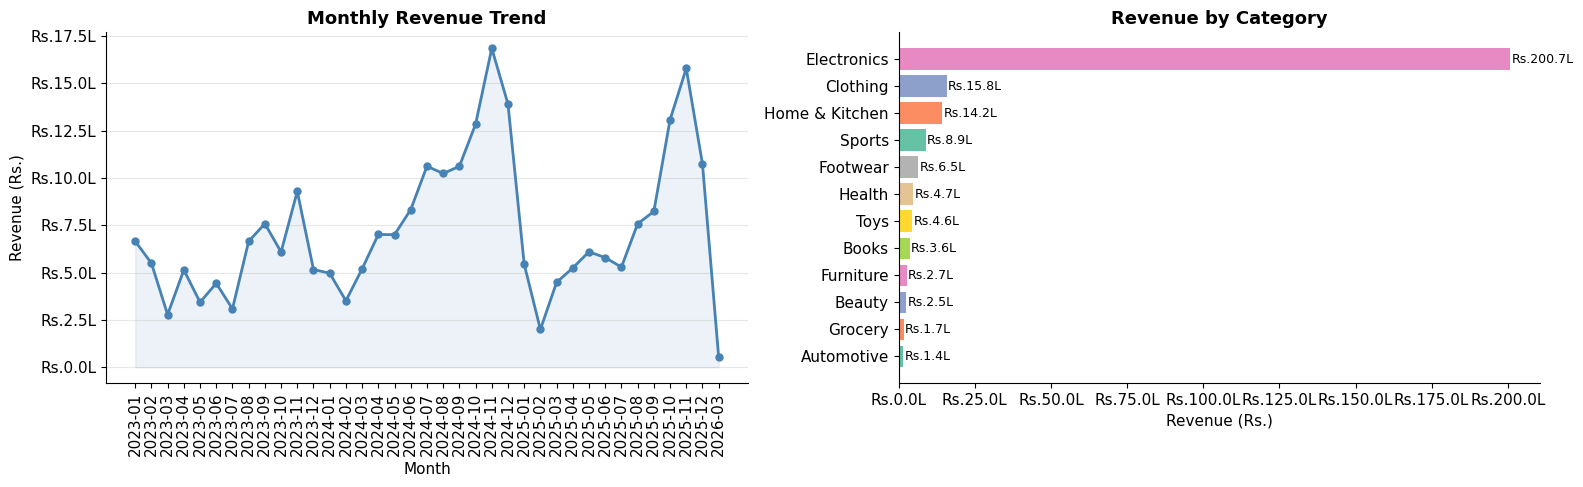


Chart saved: 01_revenue_analysis.png


In [2]:
delivered = df_order_items[df_order_items['order_status'] == 'Delivered']

print("=" * 50)
print("   REVENUE ANALYSIS")
print("=" * 50)

# Key metrics
total_revenue    = delivered['revenue'].sum()
total_orders     = delivered['order_id'].nunique()
avg_order_value  = total_revenue / total_orders
total_units      = delivered['quantity'].sum()
total_customers  = delivered['customer_id'].nunique()

print(f"\nKey Business Metrics:")
print(f"  Total Revenue       : Rs. {total_revenue:,.2f}")
print(f"  Total Orders        : {total_orders:,}")
print(f"  Avg Order Value     : Rs. {avg_order_value:,.2f}")
print(f"  Total Units Sold    : {total_units:,}")
print(f"  Unique Customers    : {total_customers:,}")

# Monthly Revenue Trend
monthly = delivered.groupby(['order_year', 'order_month'])['revenue'].sum().reset_index()
monthly['period'] = monthly['order_year'].astype(str) + '-' + monthly['order_month'].astype(str).str.zfill(2)
monthly = monthly.sort_values(['order_year', 'order_month'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1 — Monthly Revenue Trend
axes[0].plot(monthly['period'], monthly['revenue'],
             marker='o', linewidth=2, markersize=5, color='steelblue')
axes[0].fill_between(range(len(monthly)), monthly['revenue'], alpha=0.1, color='steelblue')
axes[0].set_title('Monthly Revenue Trend', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Revenue (Rs.)')
axes[0].tick_params(axis='x', rotation=90)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rs.{x/100000:.1f}L'))
axes[0].grid(axis='y', alpha=0.3)

# Plot 2 — Revenue by Category
cat_rev = delivered.groupby('category')['revenue'].sum().sort_values(ascending=True)
colors  = sns.color_palette('Set2', len(cat_rev))
axes[1].barh(cat_rev.index, cat_rev.values, color=colors)
axes[1].set_title('Revenue by Category', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Revenue (Rs.)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rs.{x/100000:.1f}L'))
for i, (val, name) in enumerate(zip(cat_rev.values, cat_rev.index)):
    axes[1].text(val + 50000, i, f'Rs.{val/100000:.1f}L', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{EDA_PATH}/01_revenue_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved: 01_revenue_analysis.png")

#### ============================================
#### EDA 2 — CUSTOMER ANALYSIS
#### ============================================

   CUSTOMER ANALYSIS

Customer Demographics:
  Total Customers  : 1,000
  Premium Members  : 176 (17.6%)
  Avg Age          : 34.8 years
  Age Range        : 18 - 64 years


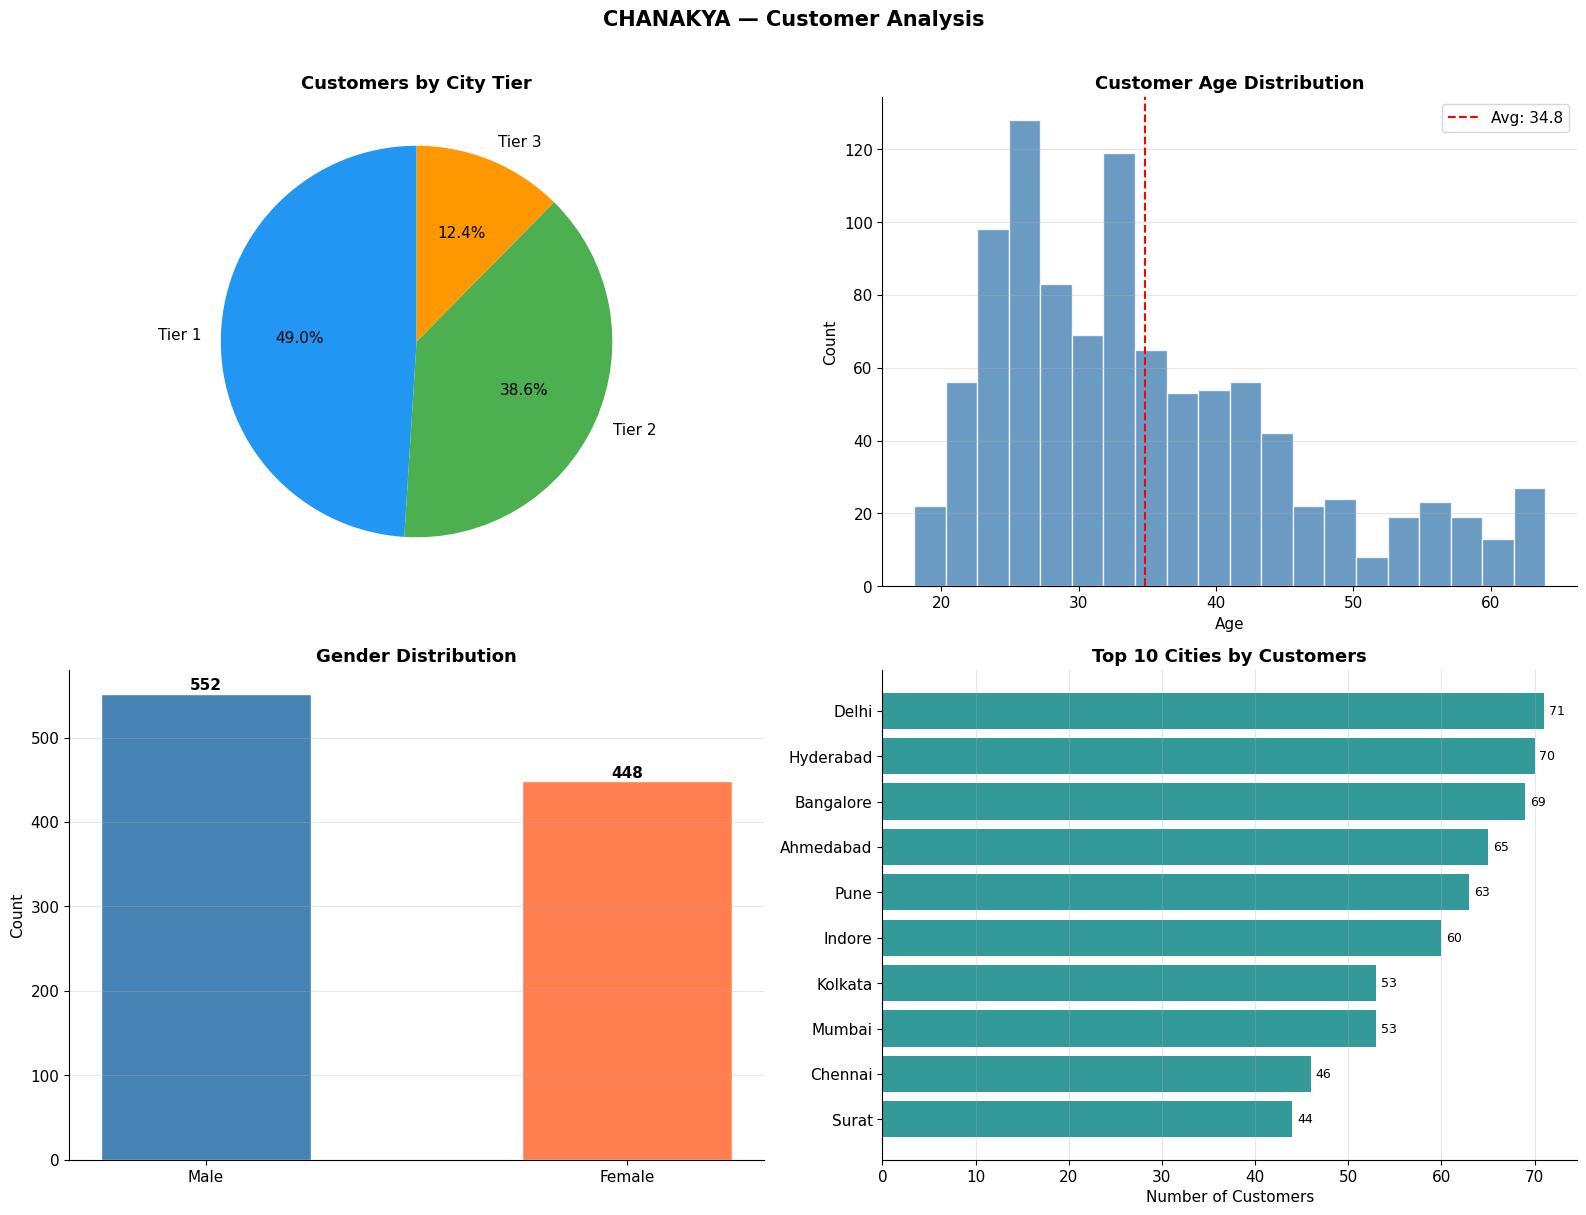


Chart saved: 02_customer_analysis.png


In [3]:
print("=" * 50)
print("   CUSTOMER ANALYSIS")
print("=" * 50)

# Customer stats
print(f"\nCustomer Demographics:")
print(f"  Total Customers  : {len(df_customers):,}")
print(f"  Premium Members  : {df_customers['is_premium'].sum():,} ({df_customers['is_premium'].mean()*100:.1f}%)")
print(f"  Avg Age          : {df_customers['age'].mean():.1f} years")
print(f"  Age Range        : {df_customers['age'].min()} - {df_customers['age'].max()} years")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1 — Customers by City Tier
tier_counts = df_customers['tier'].value_counts()
colors_tier = ['#2196F3', '#4CAF50', '#FF9800']
axes[0,0].pie(tier_counts.values, labels=tier_counts.index,
              autopct='%1.1f%%', colors=colors_tier, startangle=90)
axes[0,0].set_title('Customers by City Tier', fontsize=13, fontweight='bold')

# Plot 2 — Age Distribution
axes[0,1].hist(df_customers['age'], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
axes[0,1].set_title('Customer Age Distribution', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Age')
axes[0,1].set_ylabel('Count')
axes[0,1].axvline(df_customers['age'].mean(), color='red',
                   linestyle='--', linewidth=1.5, label=f"Avg: {df_customers['age'].mean():.1f}")
axes[0,1].legend()
axes[0,1].grid(axis='y', alpha=0.3)

# Plot 3 — Gender Split
gender_counts = df_customers['gender'].value_counts()
axes[1,0].bar(gender_counts.index, gender_counts.values,
              color=['steelblue', 'coral'], edgecolor='white', width=0.5)
axes[1,0].set_title('Gender Distribution', fontsize=13, fontweight='bold')
axes[1,0].set_ylabel('Count')
for i, val in enumerate(gender_counts.values):
    axes[1,0].text(i, val + 5, str(val), ha='center', fontweight='bold')
axes[1,0].grid(axis='y', alpha=0.3)

# Plot 4 — Top 10 Cities by Customers
top_cities = df_customers['city'].value_counts().head(10)
axes[1,1].barh(top_cities.index[::-1], top_cities.values[::-1], color='teal', alpha=0.8)
axes[1,1].set_title('Top 10 Cities by Customers', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Number of Customers')
for i, val in enumerate(top_cities.values[::-1]):
    axes[1,1].text(val + 0.5, i, str(val), va='center', fontsize=9)
axes[1,1].grid(axis='x', alpha=0.3)

plt.suptitle('CHANAKYA — Customer Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{EDA_PATH}/02_customer_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved: 02_customer_analysis.png")

#### ============================================
#### EDA 3 — ORDER ANALYSIS
#### ============================================

   ORDER ANALYSIS

Order Status:
  Delivered       : 3,508 (70.0%)
  Cancelled       : 636 (12.7%)
  Returned        : 410 (8.2%)
  Shipped         : 233 (4.7%)
  Processing      : 223 (4.5%)

Payment Methods:
  Upi                  : 1,750 (34.9%)
  Credit Card          : 998 (19.9%)
  Cash On Delivery     : 785 (15.7%)
  Debit Card           : 728 (14.5%)
  Net Banking          : 502 (10.0%)
  Emi                  : 247 (4.9%)


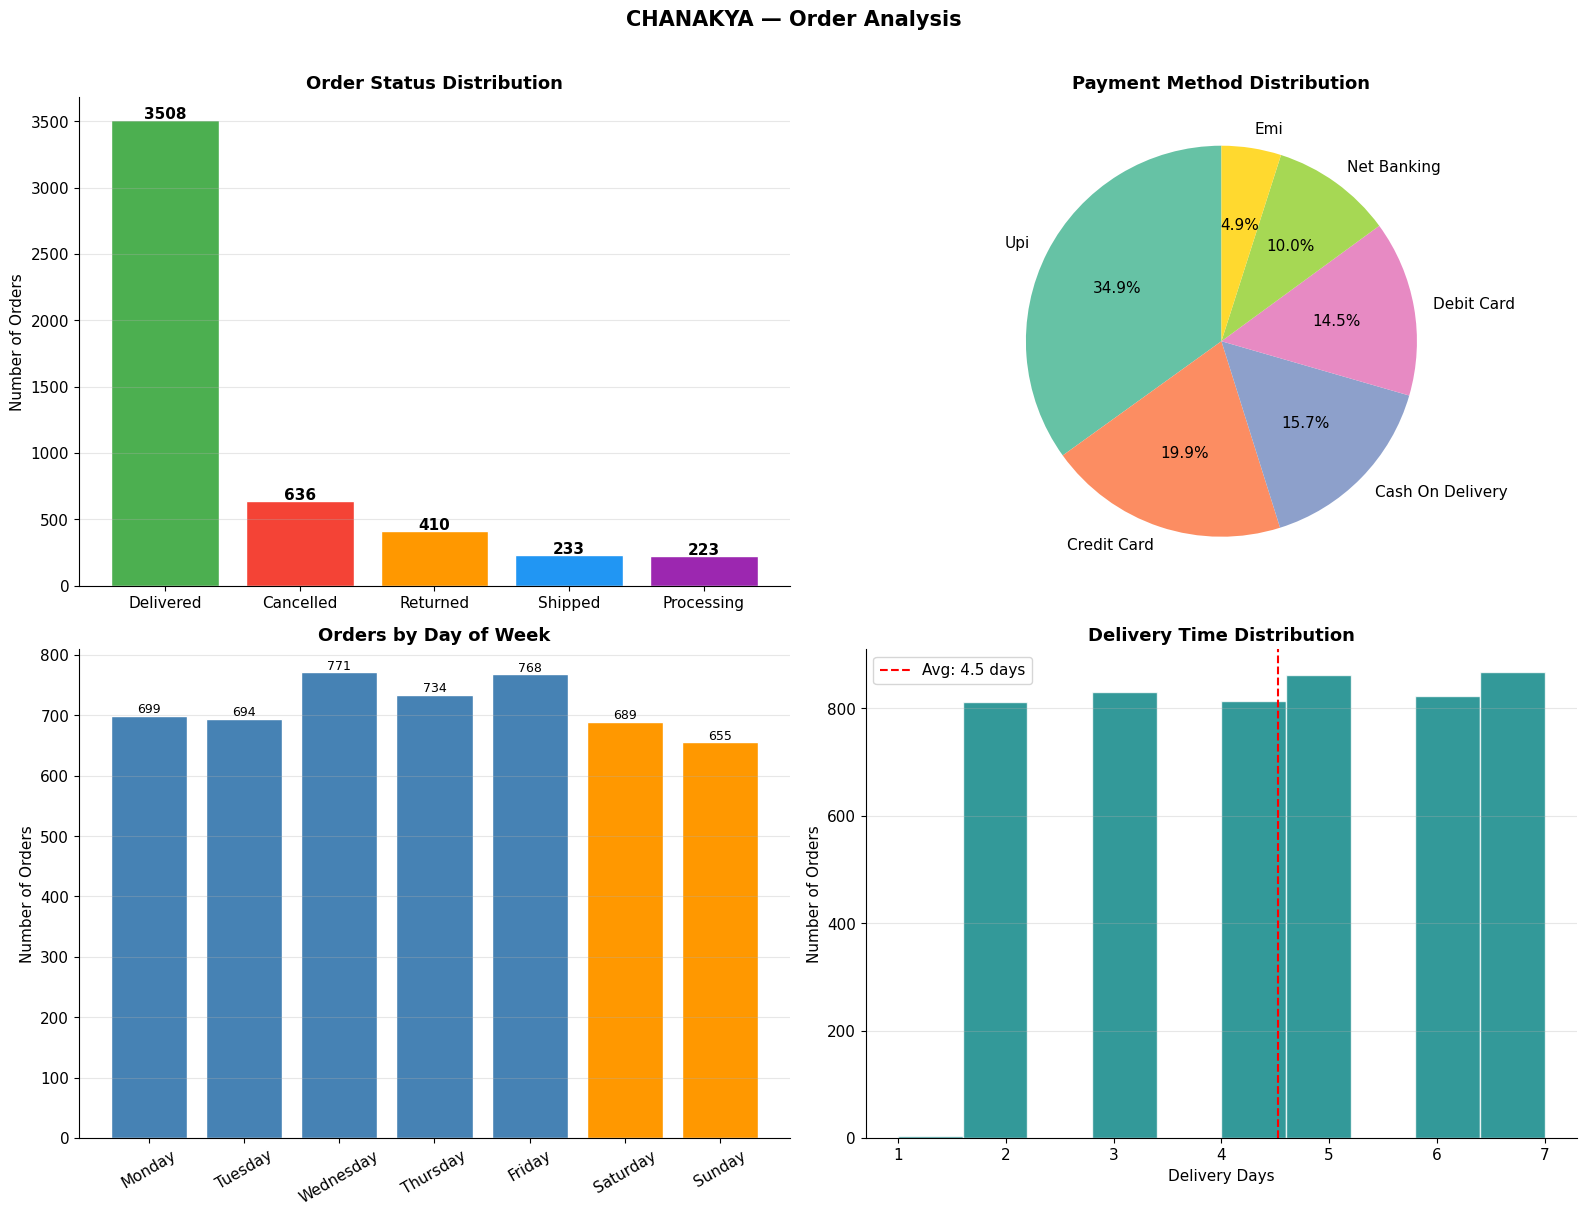


Chart saved: 03_order_analysis.png


In [4]:
print("=" * 50)
print("   ORDER ANALYSIS")
print("=" * 50)

# Order stats
status_counts  = df_orders['order_status'].value_counts()
payment_counts = df_orders['payment_method'].value_counts()

print(f"\nOrder Status:")
for status, count in status_counts.items():
    pct = count/len(df_orders)*100
    print(f"  {status:<15} : {count:,} ({pct:.1f}%)")

print(f"\nPayment Methods:")
for method, count in payment_counts.items():
    pct = count/len(df_orders)*100
    print(f"  {method:<20} : {count:,} ({pct:.1f}%)")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1 — Order Status
colors_status = ['#4CAF50', '#F44336', '#FF9800', '#2196F3', '#9C27B0']
axes[0,0].bar(status_counts.index, status_counts.values,
              color=colors_status, edgecolor='white')
axes[0,0].set_title('Order Status Distribution', fontsize=13, fontweight='bold')
axes[0,0].set_ylabel('Number of Orders')
for i, val in enumerate(status_counts.values):
    axes[0,0].text(i, val + 10, str(val), ha='center', fontweight='bold')
axes[0,0].grid(axis='y', alpha=0.3)

# Plot 2 — Payment Methods
colors_pay = sns.color_palette('Set2', len(payment_counts))
axes[0,1].pie(payment_counts.values, labels=payment_counts.index,
              autopct='%1.1f%%', colors=colors_pay, startangle=90)
axes[0,1].set_title('Payment Method Distribution', fontsize=13, fontweight='bold')

# Plot 3 — Orders by Day of Week
day_order   = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts  = df_orders['order_day'].value_counts().reindex(day_order)
colors_day  = ['#FF9800' if d in ['Saturday','Sunday'] else 'steelblue' for d in day_order]
axes[1,0].bar(day_counts.index, day_counts.values, color=colors_day, edgecolor='white')
axes[1,0].set_title('Orders by Day of Week', fontsize=13, fontweight='bold')
axes[1,0].set_ylabel('Number of Orders')
axes[1,0].tick_params(axis='x', rotation=30)
for i, val in enumerate(day_counts.values):
    axes[1,0].text(i, val + 5, str(val), ha='center', fontsize=9)
axes[1,0].grid(axis='y', alpha=0.3)

# Plot 4 — Delivery Days Distribution
axes[1,1].hist(df_orders['delivery_days'].dropna(), bins=10,
               color='teal', edgecolor='white', alpha=0.8)
axes[1,1].set_title('Delivery Time Distribution', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Delivery Days')
axes[1,1].set_ylabel('Number of Orders')
avg_delivery = df_orders['delivery_days'].mean()
axes[1,1].axvline(avg_delivery, color='red', linestyle='--',
                   linewidth=1.5, label=f'Avg: {avg_delivery:.1f} days')
axes[1,1].legend()
axes[1,1].grid(axis='y', alpha=0.3)

plt.suptitle('CHANAKYA — Order Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{EDA_PATH}/03_order_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved: 03_order_analysis.png")

#### ============================================
#### EDA 4 — PRODUCT ANALYSIS
#### ============================================

   PRODUCT ANALYSIS

Top 10 Products by Revenue:
  Product                         Units        Revenue
  ------------------------------ ------ --------------
  HP 15s Laptop                     146 Rs. 6,380,061
  Lenovo IdeaPad Slim               142 Rs. 5,220,016
  Samsung Galaxy M34                162 Rs. 2,900,197
  Redmi Smart TV 32                 165 Rs. 2,496,644
  Realme Narzo 60                   193 Rs. 2,343,070
  Cosco Cricket Kit                 189 Rs.   526,025
  Philips HL7756 Mixer              186 Rs.   493,884
  Biba Anarkali Suit                192 Rs.   397,909
  Levis Men Jeans 511               153 Rs.   358,107
  Omron BP Monitor                  186 Rs.   349,925


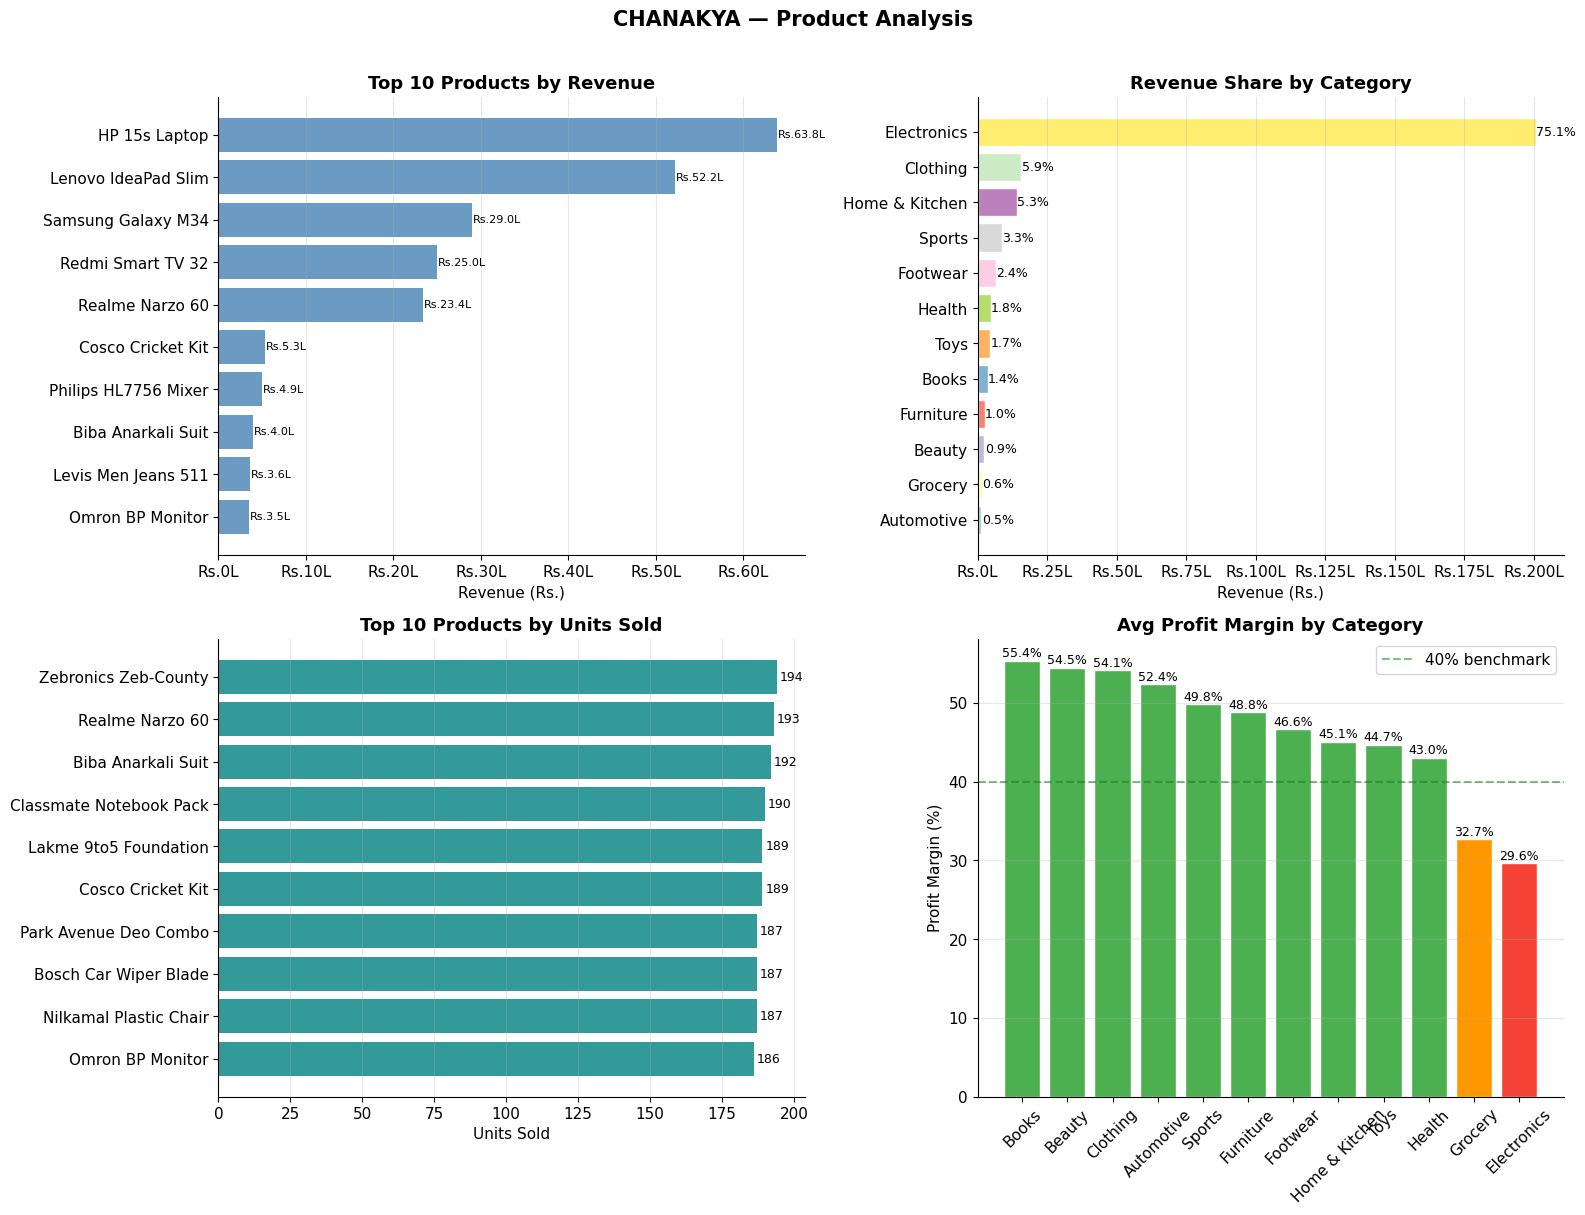


Chart saved: 04_product_analysis.png


In [6]:
print("=" * 50)
print("   PRODUCT ANALYSIS")
print("=" * 50)

delivered = df_order_items[df_order_items['order_status'] == 'Delivered']

# Top products
top_products = delivered.groupby('product_name').agg(
    units_sold  = ('quantity',   'sum'),
    revenue     = ('revenue',    'sum'),
    orders      = ('order_id',   'nunique')
).sort_values('revenue', ascending=False).head(10)

print(f"\nTop 10 Products by Revenue:")
print(f"  {'Product':<30} {'Units':>6} {'Revenue':>14}")
print(f"  {'-'*30} {'-'*6} {'-'*14}")
for name, row in top_products.iterrows():
    print(f"  {name[:30]:<30} {int(row['units_sold']):>6,} Rs.{row['revenue']:>10,.0f}")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1 — Top 10 Products by Revenue
top10_rev = top_products['revenue'].sort_values()
axes[0,0].barh(top10_rev.index, top10_rev.values, color='steelblue', alpha=0.8)
axes[0,0].set_title('Top 10 Products by Revenue', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Revenue (Rs.)')
axes[0,0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'Rs.{x/100000:.0f}L'))
for i, val in enumerate(top10_rev.values):
    axes[0,0].text(val + 10000, i, f'Rs.{val/100000:.1f}L', va='center', fontsize=8)
axes[0,0].grid(axis='x', alpha=0.3)

# Plot 2 — Category Revenue Bar Chart (pie ki jagah)
cat_rev = delivered.groupby('category')['revenue'].sum().sort_values(ascending=True)
colors  = sns.color_palette('Set3', len(cat_rev))
axes[0,1].barh(cat_rev.index, cat_rev.values, color=colors, edgecolor='white')
axes[0,1].set_title('Revenue Share by Category', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Revenue (Rs.)')
axes[0,1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'Rs.{x/100000:.0f}L'))
for i, val in enumerate(cat_rev.values):
    pct = val / cat_rev.sum() * 100
    axes[0,1].text(val + 10000, i, f'{pct:.1f}%', va='center', fontsize=9)
axes[0,1].grid(axis='x', alpha=0.3)

# Plot 3 — Top 10 Products by Units Sold
top10_units = delivered.groupby('product_name')['quantity'].sum().sort_values(
    ascending=False).head(10).sort_values()
axes[1,0].barh(top10_units.index, top10_units.values, color='teal', alpha=0.8)
axes[1,0].set_title('Top 10 Products by Units Sold', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Units Sold')
for i, val in enumerate(top10_units.values):
    axes[1,0].text(val + 1, i, str(val), va='center', fontsize=9)
axes[1,0].grid(axis='x', alpha=0.3)

# Plot 4 — Profit Margin by Category
cat_margin = df_products.groupby('category')['profit_margin'].mean().sort_values(
    ascending=False)
colors_margin = ['#4CAF50' if m >= 40 else '#FF9800' if m >= 30 else '#F44336'
                 for m in cat_margin.values]
axes[1,1].bar(cat_margin.index, cat_margin.values,
              color=colors_margin, edgecolor='white')
axes[1,1].set_title('Avg Profit Margin by Category', fontsize=13, fontweight='bold')
axes[1,1].set_ylabel('Profit Margin (%)')
axes[1,1].tick_params(axis='x', rotation=45)
for i, val in enumerate(cat_margin.values):
    axes[1,1].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontsize=9)
axes[1,1].axhline(y=40, color='green', linestyle='--', alpha=0.5, label='40% benchmark')
axes[1,1].legend()
axes[1,1].grid(axis='y', alpha=0.3)

plt.suptitle('CHANAKYA — Product Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{EDA_PATH}/04_product_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved: 04_product_analysis.png")

#### ============================================
#### LAYER 4 — EDA COMPLETE SUMMARY
#### ============================================

In [7]:
print("=" * 55)
print("   CHANAKYA — LAYER 4 COMPLETE!")
print("   Exploratory Data Analysis")
print("=" * 55)

delivered = df_order_items[df_order_items['order_status'] == 'Delivered']

print("\nKEY BUSINESS INSIGHTS:")
print("-" * 55)

# Revenue insights
total_rev   = delivered['revenue'].sum()
top_cat     = delivered.groupby('category')['revenue'].sum().idxmax()
top_cat_pct = delivered.groupby('category')['revenue'].sum().max() / total_rev * 100
top_product = delivered.groupby('product_name')['revenue'].sum().idxmax()
peak_month  = delivered.groupby('order_month')['revenue'].sum().idxmax()

print(f"\n  Revenue Insights:")
print(f"    Total Revenue     : Rs. {total_rev:,.2f}")
print(f"    Top Category      : {top_cat} ({top_cat_pct:.1f}% of revenue)")
print(f"    Best Product      : {top_product}")
print(f"    Peak Month        : Month {peak_month} (November)")

# Customer insights
print(f"\n  Customer Insights:")
print(f"    Total Customers   : {len(df_customers):,}")
print(f"    Avg Age           : {df_customers['age'].mean():.1f} years")
print(f"    Top City          : {df_customers['city'].value_counts().idxmax()}")
print(f"    Premium Members   : {df_customers['is_premium'].sum()} ({df_customers['is_premium'].mean()*100:.1f}%)")
print(f"    Gender Split      : Male {(df_customers['gender']=='Male').sum()} | Female {(df_customers['gender']=='Female').sum()}")

# Order insights
print(f"\n  Order Insights:")
print(f"    Delivery Rate     : {(df_orders['order_status']=='Delivered').mean()*100:.1f}%")
print(f"    Cancellation Rate : {(df_orders['order_status']=='Cancelled').mean()*100:.1f}%")
print(f"    Top Payment       : {df_orders['payment_method'].value_counts().idxmax()}")
print(f"    Avg Delivery Days : {df_orders['delivery_days'].mean():.1f} days")
print(f"    Peak Order Day    : {df_orders['order_day'].value_counts().idxmax()}")

# Product insights
print(f"\n  Product Insights:")
print(f"    Total Products    : {len(df_products)}")
print(f"    Total Categories  : {df_products['category'].nunique()}")
print(f"    Avg Profit Margin : {df_products['profit_margin'].mean():.1f}%")
print(f"    Best Margin Cat   : {df_products.groupby('category')['profit_margin'].mean().idxmax()}")
print(f"    Low Margin Cat    : {df_products.groupby('category')['profit_margin'].mean().idxmin()}")

print("\nCHARTS SAVED:")
print("-" * 55)
print(f"  01_revenue_analysis.png")
print(f"  02_customer_analysis.png")
print(f"  03_order_analysis.png")
print(f"  04_product_analysis.png")

print("\nINTERVIEW READY — KEY POINTS:")
print("-" * 55)
print(f"  1. Univariate analysis — single variable distributions")
print(f"  2. Bivariate analysis  — revenue vs category, city vs orders")
print(f"  3. Time series        — monthly revenue trend identified")
print(f"  4. Business insights  — actionable recommendations")
print(f"  5. Visual storytelling — 4 professional chart sets")

print("\nDATA READY FOR:")
print(f"  Layer 5 — RFM + Customer Segmentation")
print(f"  Layer 6 — Anomaly Detection")

print("\n" + "=" * 55)
print("   LAYER 4 COMPLETE — EDA Done!")
print("=" * 55)

   CHANAKYA — LAYER 4 COMPLETE!
   Exploratory Data Analysis

KEY BUSINESS INSIGHTS:
-------------------------------------------------------

  Revenue Insights:
    Total Revenue     : Rs. 26,713,763.75
    Top Category      : Electronics (75.1% of revenue)
    Best Product      : HP 15s Laptop
    Peak Month        : Month 11 (November)

  Customer Insights:
    Total Customers   : 1,000
    Avg Age           : 34.8 years
    Top City          : Delhi
    Premium Members   : 176 (17.6%)
    Gender Split      : Male 552 | Female 448

  Order Insights:
    Delivery Rate     : 70.0%
    Cancellation Rate : 12.7%
    Top Payment       : Upi
    Avg Delivery Days : 4.5 days
    Peak Order Day    : Wednesday

  Product Insights:
    Total Products    : 50
    Total Categories  : 12
    Avg Profit Margin : 44.8%
    Best Margin Cat   : Books
    Low Margin Cat    : Electronics

CHARTS SAVED:
-------------------------------------------------------
  01_revenue_analysis.png
  02_customer_anal